## Seaborn

[Seaborn](https://seaborn.pydata.org/) è un'altra libreria di visualizzazione più moderna e semplice da usare. È sempre basata su matplotlib, per cui non potevo presentarvela senza farvi vedere matplotlib. Se volete usarla per il progetto non c'è problema, il funzionamento è simile a matplotlib e ha un'ottima documentazione. Iniziamo installando la libreria:

In [ ]:
!python -m pip install seaborn

Importiamo le librerie che useremo oggi:

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Seaborn crea grafici integrandosi con `pandas`. Vediamo come fare a disegnare un bar plot con due categorie partendo da un dataset di esempio "penguins" che è fornito con la libreria.

In [ ]:
#penguins = sns.load_dataset("penguins")
# se non scarica
penguins = pd.read_csv("data/penguins.csv")

penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


La funzione `barplot` crea un bar chart. Vediamo come funziona:

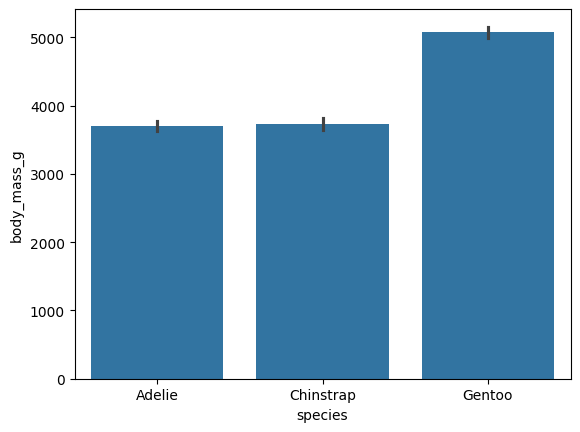

In [3]:
sns.barplot(
    data=penguins,
    x="species", y="body_mass_g"
)
plt.show()

- `data` indica il DataFrame che vogliamo visualizzare,
- `x` specifica con cosa popolare l'asse orizzontale, 
- `y` l'asse verticale, 

Rispetto a Matplotlib, notate che il sistema ha già prodotto un'altezza media dei pinguini e ci offre anche un intervallo di confidenza. Possiamo cambiare che valore usare come intervallo usando il parametro `errorbar`.

Nel dataset, oltre all'altezza dei pinguini, ho a disposizione anche informazioni sul loro sesso. Come posso mostrare questo dato? Devo usare l'opzione `hue`.

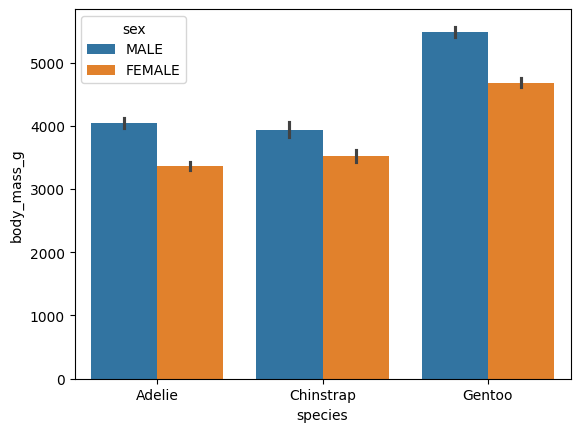

In [6]:
# Draw a nested barplot by species
sns.barplot(
    data=penguins,
    x="species", y="body_mass_g", hue="sex"
)
plt.show()

Notate che i nomi degli assi sono stati impostati automaticamente. Per cambiarli dovrei usare un approccio leggermente diverso che sfrutta la funzione `catplot`, che supporta tutti i tipi di grafico che operano su dati categorici:

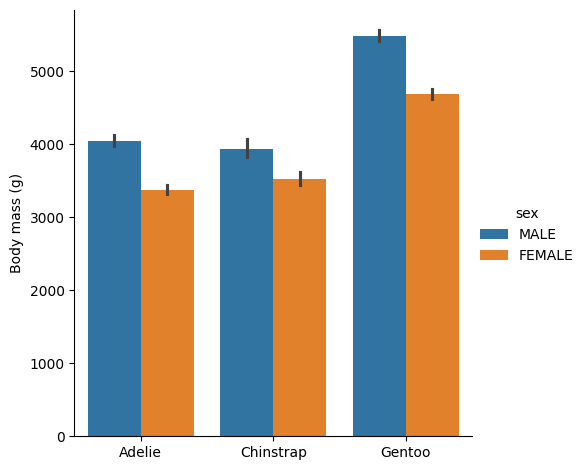

In [9]:
g = sns.catplot(
    data=penguins, kind="bar",
    x="species", y="body_mass_g", hue="sex",
)
g.set_axis_labels("", "Body mass (g)")
plt.show()

Mentre barplot ritorna un `Axes`, `catplot` ritorna un oggetto di tipo `FacetGrid` che ci consente di sistemare i nomi degli assi.

In questo caso seaborne fa la media dei valori di body mass dei pinguini di ciascuna specie. E se invece volessimo replicare il grafico a barre per import/export visto nell'ultima lezione? 
Ripartiamo dai dati di importazione ed esportazione della scorsa lezione:

In [10]:
countries = ["Italy", "France", "Germany", "China", "USA"]
import_export_df = pd.DataFrame({"country": countries,"import" : [640, 786, 1476, 2557, 3172],
    "export" : [677, 649, 1718, 3379, 2021]})

import_export_df

,country,import,export
0,Italy,640,677
1,France,786,649
2,Germany,1476,1718
3,China,2557,3379
4,USA,3172,2021


Dobbiamo ora usare il metodo "melt", che trasforma una tabella da formato "wide" a formato "long". Vediamo come funziona:

In [11]:
tidy = import_export_df.melt(id_vars="country") # creiamo una tabella in cui le due colonne "import" e "export" 
                                                # sono separate in due righe per ogni paese

tidy

,country,variable,value
0,Italy,import,640
1,France,import,786
2,Germany,import,1476
3,China,import,2557
4,USA,import,3172
5,Italy,export,677
6,France,export,649
7,Germany,export,1718
8,China,export,3379
9,USA,export,2021


Possiamo quindi fare il grafico a barre:

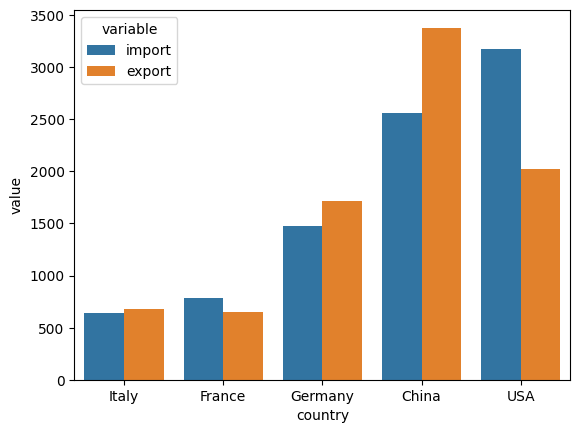

In [12]:
g = sns.barplot(
    data=tidy, x="country", y="value", hue="variable"
)
plt.show()

## Scatterplot

Per creare uno scatterplot in seaborn, possiamo usare il dataset di esempio `tips` che è già incluso con la libreria:

In [13]:
#tips = sns.load_dataset("tips")

tips = pd.read_csv("data/tips.csv")

tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Siamo interessati a fare uno scatterplot che ci mostra la dimensione della mancia (`tip`) al variare del prezzo totale del pasto (`total_bill`). Per fare questa operazione possiamo sfruttare la funzione `scatterplot`. Vediamo come:

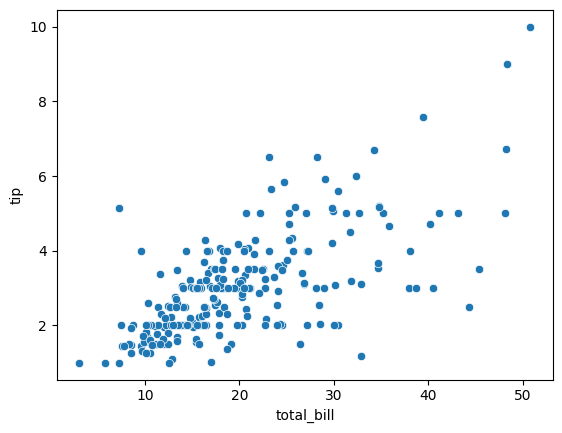

In [14]:
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.show()

Anche in questo caso però potrei voler colorare i punti del mio scatterplot, per esempio a seconda del fatto che si tratti di pranzo o cena, usando la colonna `time`. Vediamo come fare: 

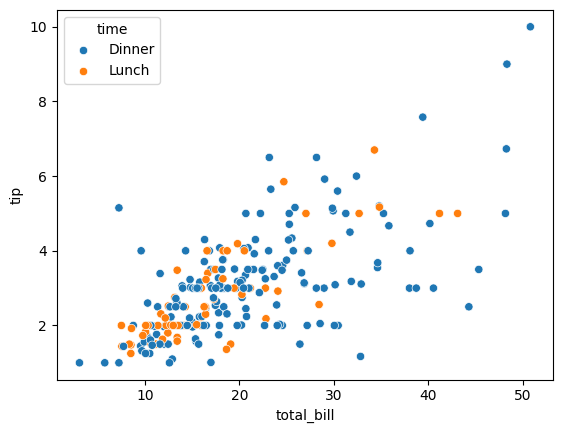

In [15]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.show()

# Istogrammi

Un istogramma è un grafico che mostra una distribuzione di valori continui. Per effettuare questa operazione, questi valori continui vengonon divisi in *bins*, ovvero intervalli. In questo modo possiamo ottenere un'idea di come si comporti una variabile. Vediamo come usare questa funzionalità in seaborn: 

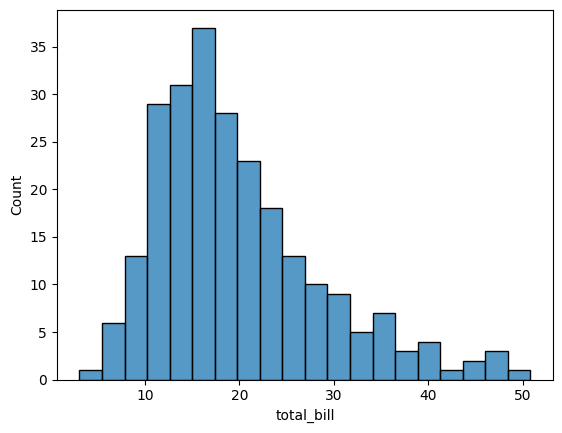

In [18]:
sns.histplot(data=tips, x="total_bill", bins=20)
plt.show()

Se io volessi comparare la distribuzione dei prezzi totali a seconda se si tratti di pranzo o cena, potrei di nuovo usare `hue` come segue:

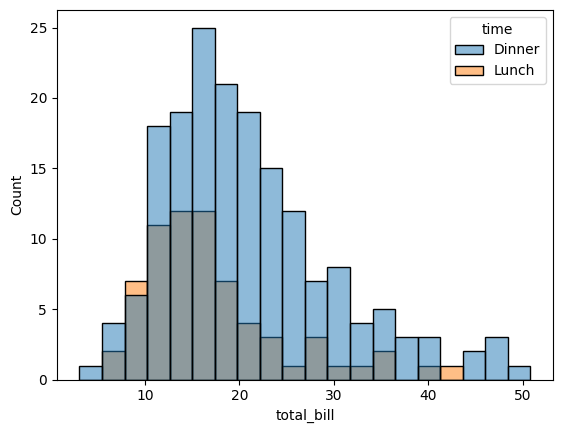

In [19]:
sns.histplot(data=tips, x="total_bill", hue="time", bins=20)
plt.show()

# Countplot

In molti casi può succedere di voler contare quante volte appare una variabile categorica (non un numero, tipicamente una stringa) all'interno di un dataset. Per fare questa operazione posso sfruttare `countplot` come segue:

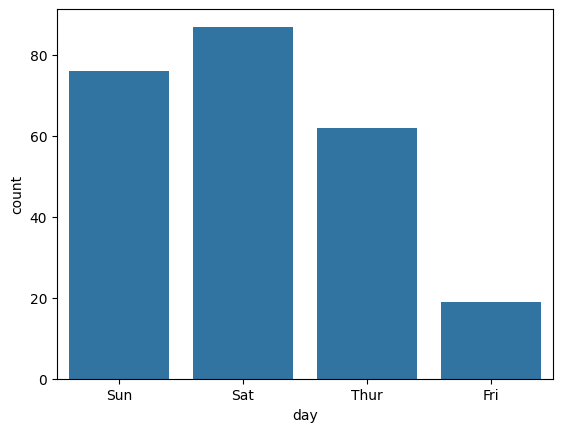

In [20]:
sns.countplot(data=tips, x="day")
plt.show()

Volendo è possibile creare due barre, una per ciascun pasto:

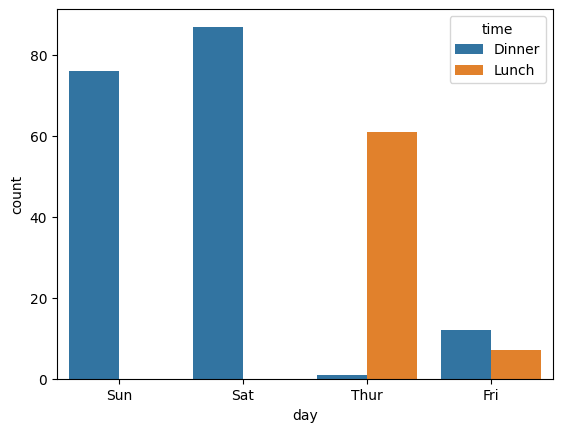

In [23]:
sns.countplot(data=tips, x="day", hue="time")
plt.show()

## Box plot

Come in matplotlib, anche con Seaborn possiamo creare boxplot:

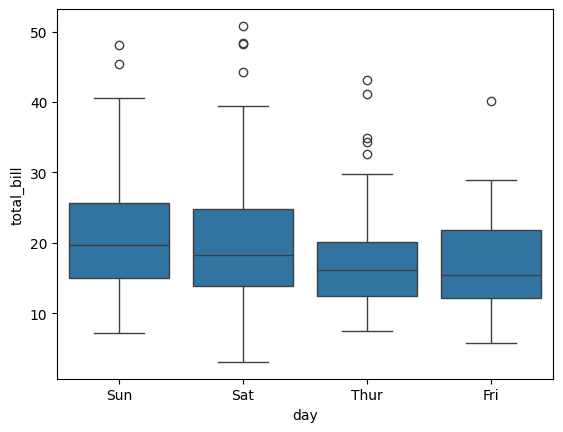

In [24]:
sns.boxplot(data=tips, x="day", y="total_bill")
plt.show()

### Quiz:

1. Come faremmo a ottenere un box plot con le spese totali per ciascun giorno della ?

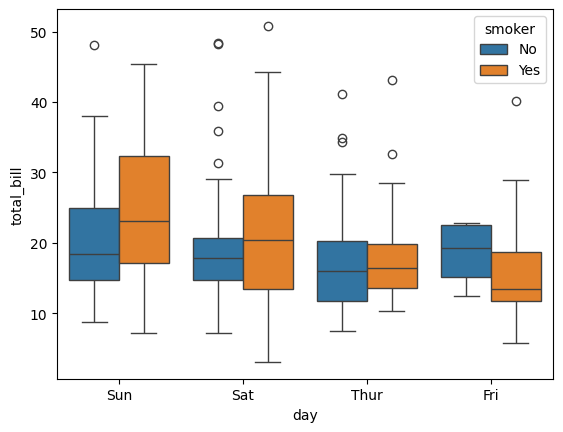

In [26]:
# ES1
sns.boxplot(data=tips, x="day", y="total_bill", hue="smoker")
plt.show()

## Violin Plot

I violin plot sono un tipo di grafico particolarmente utile per visualizzare la forma di una o più distribuzioni. Contengono le stesse informazioni di un box plot (quartili, mediana) ma ci consentono di osservare il comportamento complessivo della distribuzione.

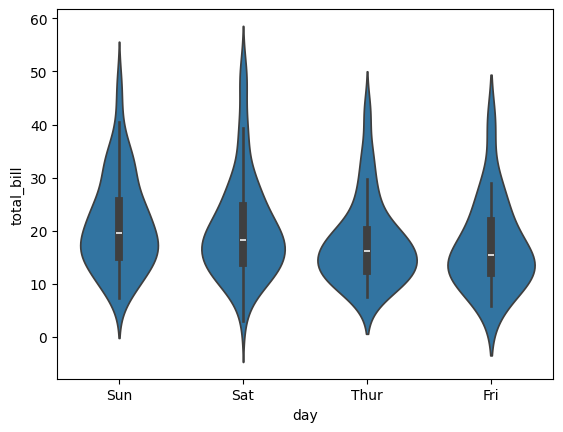

In [27]:
sns.violinplot(data=tips, x="day", y="total_bill")
plt.show()

### Quiz

1. E se io volessi mostrare anche le differenze fra pranzo e cena?

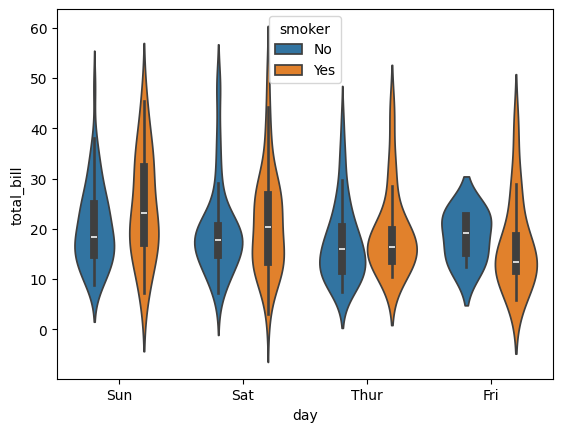

In [30]:
# ES1
sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker")
plt.show()

## Regression Plot

Un task classico riguarda lo studio della relazione fra due variabili. Per effettuare questa operazione uno strumento molto utile è quello della **regressione**. Si tratta di un semplice modello statistico che ci mostra come le due variabili sono correlate fra loro. Per esempio potremmo ragionare su prezzo di un pasto e mancia e chiederci se ci sia una relazione fra di essi. Per visualizzare una regressione possiamo usare `regplot`:

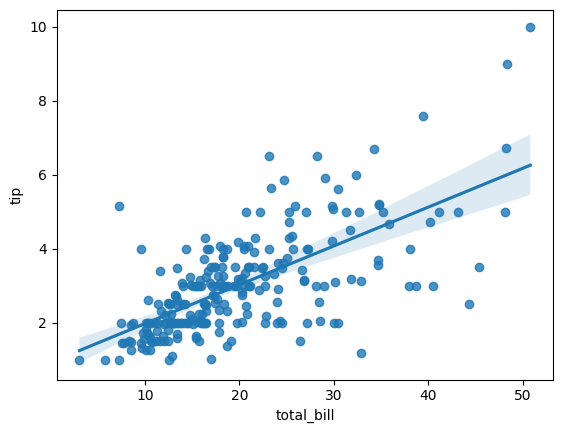

In [31]:
sns.regplot(data=tips, x="total_bill", y="tip")
plt.show()

## Heatmap

L'ultima tipologia di grafico che vediamo oggi si chiama **heatmap** e viene usata per mostrare il comportamento di una terza variabile al variare di altre due. La heatmap quindi è una griglia bidimensionale che viene colorata secondo un gradiente di colori per mostrare maggiori o minori valori di una terza variabile. Per effettuare questo esperimento, usiamo un altro dataset di seaborne che misura il numero di voli per ciascun mese dell'anno:

In [35]:
flights = sns.load_dataset("flights")

#se non funziona
#flights = pd.read_csv("data/flights.csv")

flights


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


Prima di usare questi dati però, dobbiamo convertirli in una matrice 2d:

In [36]:
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

flights_pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


Infine, possiamo visualizzare i dati:

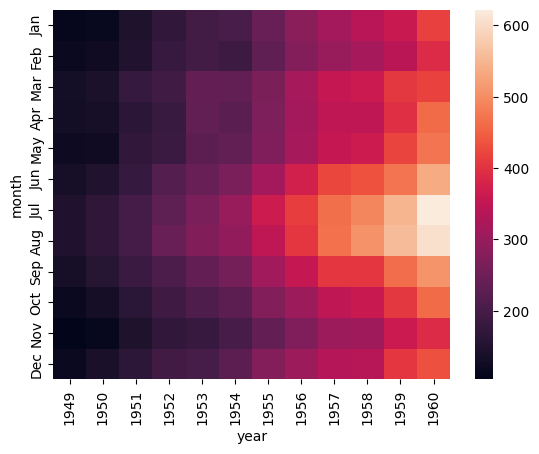

In [37]:
sns.heatmap(flights_pivot)
plt.show()

# Quiz

1. La variabile `python_descr` nella cella sottostante contiene l'inizio della descrizione della pagina "Python" su Wikipedia italia. Crea uno script che calcola il numero di occorrenze di ciascun carattere (quindi anche punteggiatura, spazi) e crea un grafico a barre che mostra i 10 caratteri più frequenti usando seaborn.

In [38]:
python_descr = """
Python è un linguaggio di programmazione ad alto livello, orientato a oggetti, adatto, tra gli altri usi, a sviluppare applicazioni distribuite, scripting, computazione numerica e system testing.

Ideato dall'olandese Guido van Rossum all'inizio degli anni novanta, è spesso paragonato a Ruby, Tcl, Perl, JavaScript, Visual Basic o Scheme[1]. Il nome fu scelto per la passione dello stesso inventore verso i Monty Python e per la loro serie televisiva Monty Python's Flying Circus[2].

Spesso è tra i primi linguaggi di programmazione a essere studiati dai neofiti, per la sua somiglianza a uno pseudo-codice, e di frequente viene usato per simulare la creazione di software grazie alla flessibilità di sperimentazione consentita, che permette al programmatore di organizzare le idee durante lo sviluppo, come per esempio il creare un gioco tramite Pygame oppure il back-end di un sito web tramite Flask o Django.

Python dispone anche di una sezione grafica, il modulo Python Turtle Graphics, che permette di applicare le righe di codici alla grafica.
Descrizione

È un linguaggio che ha tra i principali obiettivi: dinamicità, semplicità e flessibilità. Python è un linguaggio semplice, che è stato progettato appositamente per essere facilmente comprensibile, la cui sintassi si avvicina estremamente al linguaggio naturale (incorporandone alcuni aspetti). Inoltre la potenza di Python è sicuramente il fatto di essere altamente flessibile, prestandosi ad un ampio spettro di utilizzi grazie alle sue numerose librerie.[non chiaro]. Supporta multipli paradigmi di programmazione, tra cui quello a oggetti e quello funzionale.

Le caratteristiche più immediatamente riconoscibili di Python sono le variabili non tipizzate e l'uso dell'indentazione per la sintassi delle specifiche, al posto delle più comuni parentesi.

Altre caratteristiche distintive sono l'overloading di operatori e funzioni tramite delegati, la presenza di un ricco assortimento di tipi e funzioni di base e librerie standard, sintassi avanzate quali slicing e list comprehension.

Il controllo dei tipi è forte (strong typing) e viene eseguito a run-time (dynamic typing): una variabile è un contenitore a cui viene associata un'etichetta (il nome) che può essere associata a diversi contenitori anche di tipo diverso durante il suo tempo di vita. Fa parte di Python un sistema garbage collector per la liberazione e il recupero automatici della memoria con cui si lavora.

Python ha qualche somiglianza con Perl, ma i suoi progettisti hanno scelto una sintassi più essenziale e uniforme con l'obiettivo di migliorare la leggibilità del codice. Analogamente a Perl è classificato spesso come linguaggio di scripting, ma pur essendo utile per scrivere script di sistema, in alternativa per esempio a bash, la grande quantità di librerie disponibili e la facilità con cui il linguaggio permette di scrivere software modulare favoriscono anche lo sviluppo di applicazioni molto complesse.
"""

[ 19 103  19 174  32 184 159 432  10  79 147 307  66 223  76 143  70  30
 273  32  29 146  93  23  16   8   2   3   1   3  24   1   3   6   3   7
   2   2   4   4   3   1]


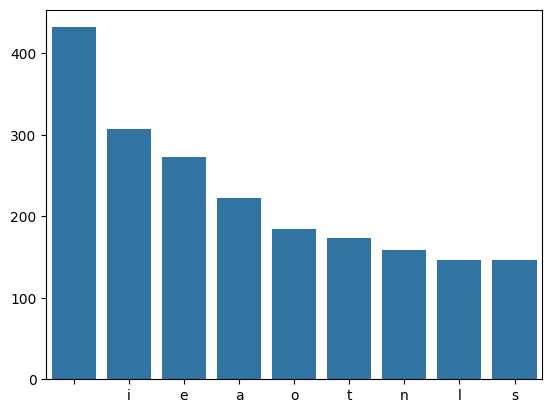

In [62]:
# ES1

from collections import Counter
import numpy as np

# usando un dizionario
count_characters = {}
for char in python_descr.lower():
    if char not in count_characters:
        count_characters[char] = 0
    
    count_characters[char] += 1

# usando Counter
count_characters = Counter(python_descr.lower())

characters_array = np.array(list(count_characters.keys()))
count_array = np.array(list(count_characters.values()))
print(count_array)

first_10_indices = np.argsort(count_array)[-1:-10:-1]
first_10_characters = characters_array[first_10_indices]
first_10_counts = count_array[first_10_indices]

sns.barplot(x=first_10_characters, y=first_10_counts)
plt.show()